In [7]:
import pandas as pd 

In [9]:
from sklearn.datasets import fetch_california_housing

In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [12]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [13]:
df = fetch_california_housing()

In [14]:
dataset = pd.DataFrame(df.data)

In [19]:
dataset.columns = df.feature_names

In [21]:
X = dataset 
y = df.target

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [29]:
X_train= scaler.transform(X_train)

C:\Users\arvin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [31]:
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LinearRegression

In [35]:
#cross validation 
from sklearn.model_selection import cross_val_score

In [37]:
regression = LinearRegression()

In [39]:
regression.fit(X_train,y_train)

LinearRegression()

In [41]:
mse = cross_val_score(regression , X_train , y_train , scoring = 'neg_mean_squared_error',cv=5)

In [43]:
np.mean(mse)

-0.526825374635575

In [45]:
reg_pred = regression.predict(X_test)

In [47]:
reg_pred

array([75.39904685, 77.64758448, 81.9468823 , ..., 74.04218911,
       71.25418692, 74.51758511])

In [49]:
import seaborn as sns

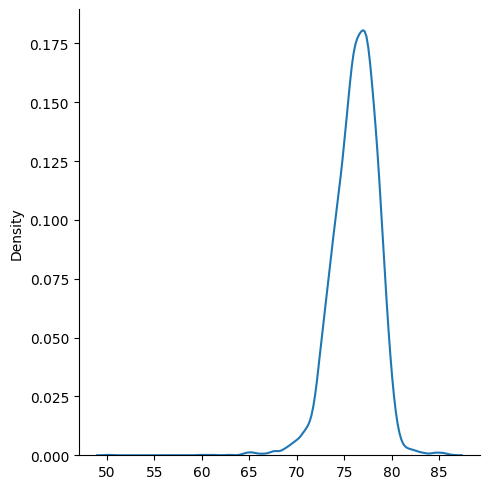

In [51]:
sns.displot(reg_pred-y_test,kind = "kde")

In [52]:
from sklearn.metrics import r2_score

In [53]:
score = r2_score(reg_pred , y_test)

In [54]:
score

-759.6180217573941

In [55]:
from sklearn.linear_model import Ridge 
from sklearn.model_selection import GridSearchCV

In [56]:
ridge_regressor = Ridge()

In [57]:
ridge_regressor

Ridge()

In [58]:
parameters = {'alpha' :[1,2,5,10,20,30,45,50,60,70,90]}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv =5)
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 45, 50, 60, 70, 90]},
             scoring='neg_mean_squared_error')

In [59]:
ridgecv.best_params_

{'alpha': 5}

In [60]:
ridgecv.best_score_

-0.5257421299485877

In [61]:
ridge_pred = ridgecv.predict(X_test)

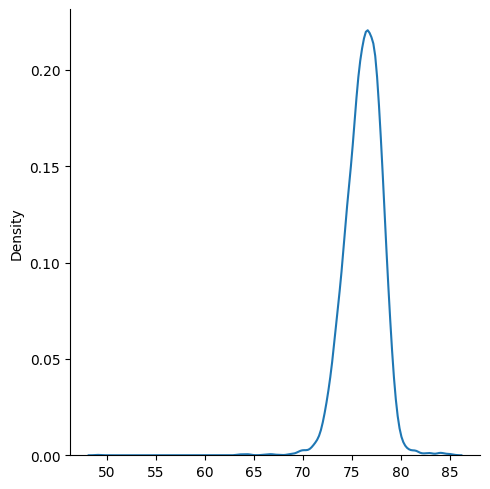

In [63]:
sns.displot(ridge_pred-y_test,kind='kde')

In [64]:
score = r2_score(ridge_pred,y_test)

In [67]:
score

-1026.230231267819

In [68]:
##lasso regression 
from sklearn.linear_model import Lasso

In [72]:
lasso_regressor = Lasso()

In [74]:
parameters = {'alpha' :[1,2,5,10,20,30,45,50,60,70,90]}
lassocv = GridSearchCV(lasso_regressor,parameters,scoring='neg_mean_squared_error',cv =5)
lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 45, 50, 60, 70, 90]},
             scoring='neg_mean_squared_error')

In [75]:
print(lassocv.best_score_)
print(lassocv.best_params_)

-1.3400019579636542
{'alpha': 1}


In [76]:
lasso_pred = lassocv.predict(X_test)

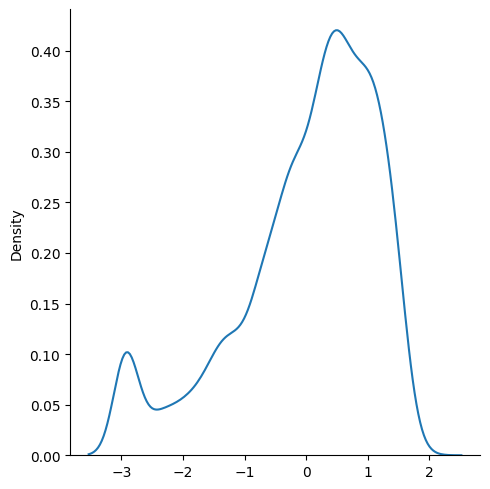

In [78]:
sns.displot(lasso_pred-y_test,kind='kde')

In [80]:
score = r2_score(lasso_pred,y_test)

In [83]:
score

0.0